# HW10: Outlier detection

In [52]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning) 

import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd  
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, KFold,\
RepeatedKFold
from sklearn.ensemble import  RandomForestRegressor, GradientBoostingRegressor
import statsmodels.api as sm
from sklearn.metrics import r2_score
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import het_white
from tqdm.notebook import tqdm
from sklearn.datasets import load_boston

In [2]:
%matplotlib inline
%load_ext pycodestyle_magic

In [3]:
def load_housing_data_frame(verbose=True):
    raw = load_boston()
    data_frame = pd.DataFrame(raw.data, columns=raw.feature_names)
    data_frame['PRICE'] = raw.target
    if verbose:
        print(raw.DESCR)
    return data_frame

In [4]:
def plot_cv_results(cv_results, param_x, param_z, metric='mean_test_score'):
    """
    cv_results - cv_results_ attribute of a GridSearchCV instance (or similar)
    param_x - name of grid search parameter to plot on x axis
    param_z - name of grid search parameter to plot by line color
    """
    cv_results = pd.DataFrame(cv_results)
    col_x = 'param_' + param_x
    col_z = 'param_' + param_z
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    sns.pointplot(x=col_x, y=metric, hue=col_z, data=cv_results, ci=99, n_boot=64, ax=ax)
    plt.xticks(rotation=90)
    ax.set_title("CV Grid Search Results")
    ax.set_xlabel(param_x)
    ax.set_ylabel(metric)
    ax.legend(title=param_z)

## Loading the data

In [5]:
df = load_housing_data_frame()

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

In [6]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Looking for correlations

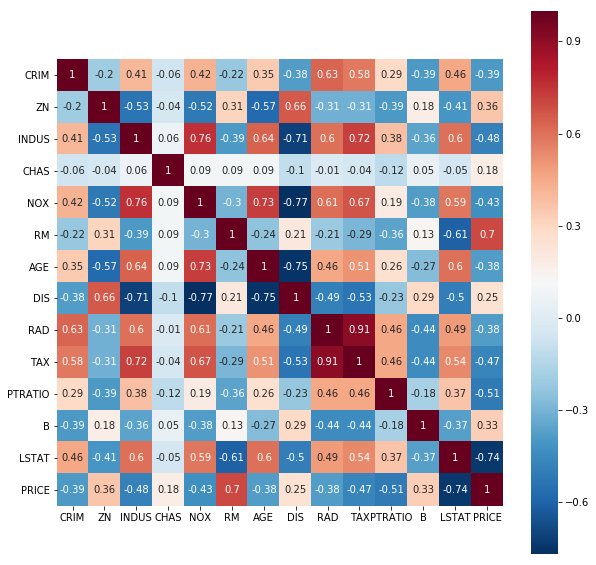

In [7]:
plt.figure(figsize=(10,10))
correlation_matrix = df.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True,
            cmap = 'RdBu_r', square=True)

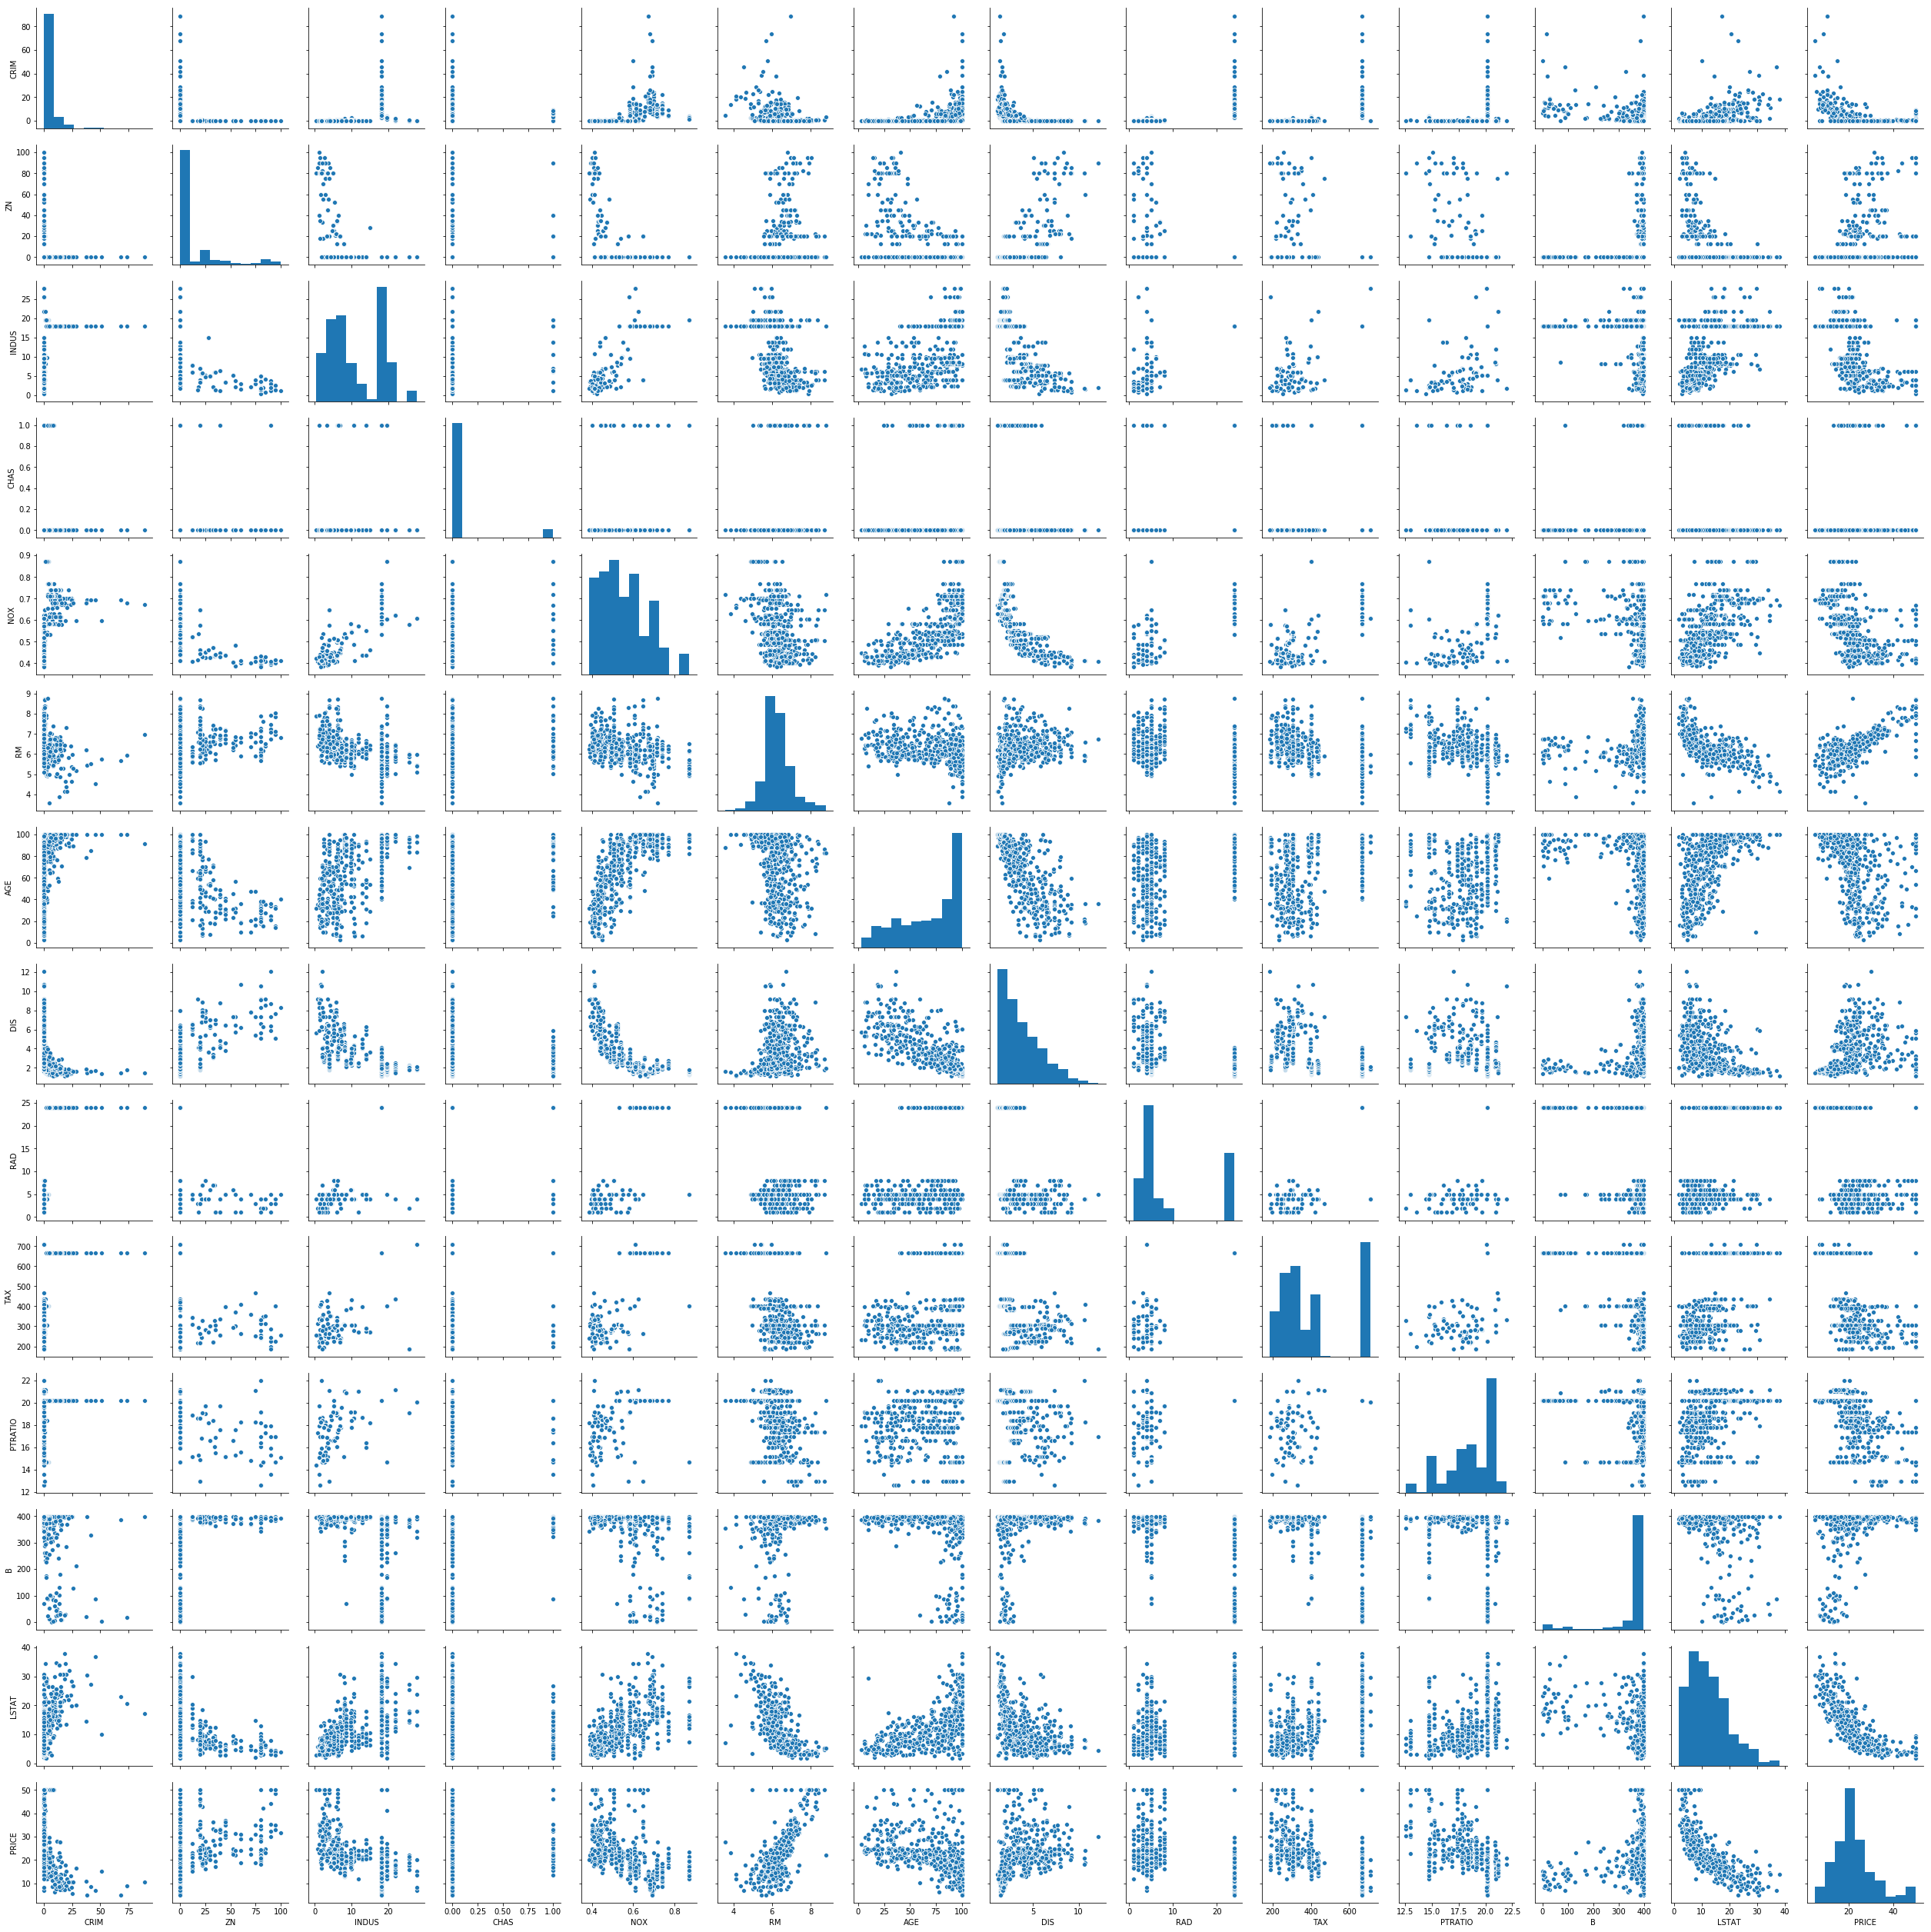

In [7]:
sns.pairplot(df)

## Most promising features

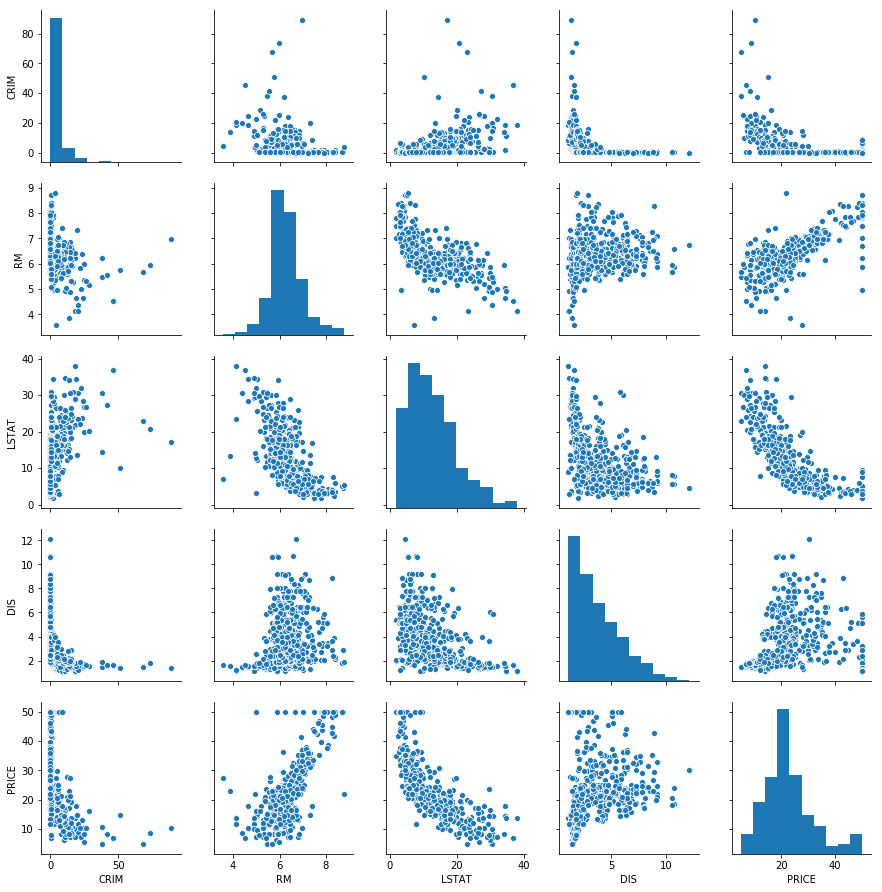

In [8]:
sns.pairplot(df, vars=['CRIM', 'RM',
                       'LSTAT','DIS',
                       'PRICE'])

In [9]:
df['DIS'] = np.log(df['DIS'])
df['CRIM'] = -np.log(df['CRIM'])
df['LSTAT'] = -np.log(df['LSTAT'])

## Model

### Gradient Boosting Regression

GridSearch with raw data

In [10]:
features = df.columns[df.columns != 'PRICE']

In [11]:
X_train, X_test, y_train, y_test = \
    train_test_split(df.loc[:, features],
                     df.loc[:, 'PRICE'],
                     test_size=0.3, random_state=42)

In [12]:
rf_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid={
        'criterion': ['mae', 'mse'],
        'max_depth': np.arange(1, 10, 1),
        'n_estimators': np.arange(1, 20, 2),
        'min_samples_split': [2],
        'min_samples_leaf': [1],
        'max_features': ['auto', 'sqrt']
    },
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 976 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 1785 out of 1800 | elapsed:   12.3s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 1800 out of 1800 | elapsed:   12.3s finished
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/sklearn/model_selection/_search.py:814: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=GradientBoostingRegressor(alpha=0.9,
                                                 criterion='friedman_mse',
                                                 init=None, learning_rate=0.1,
                                                 loss='ls', max_depth=3,
                                                 max_features=None,
                                                 max_leaf_nodes=None,
                                                 min_impurity_decrease=0.0,
                                                 min_impurity_split=None,
                                                 min_samples_leaf=1,
                                                 min_samples_split=2,
                                                 min_weight_fraction_leaf=0.0,
                                                 n_estimators=100,
                                                 n_iter...
                             

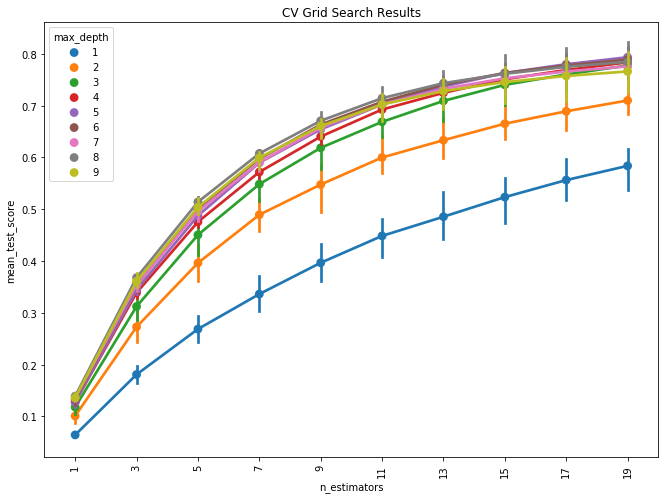

In [13]:
plot_cv_results(rf_grid.cv_results_, 'n_estimators', 'max_depth')

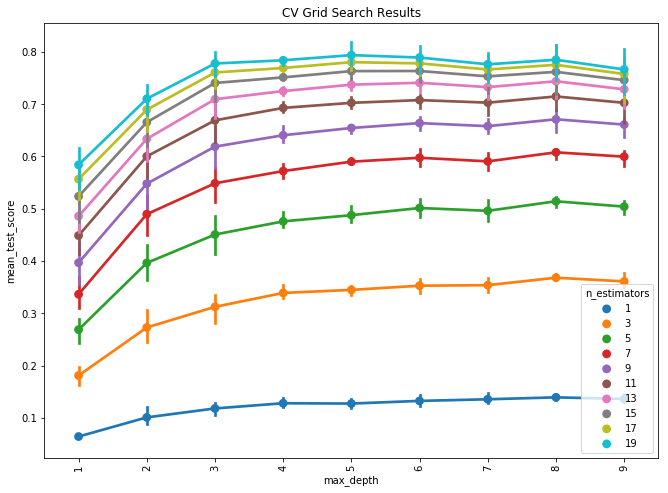

In [14]:
plot_cv_results(rf_grid.cv_results_, 'max_depth', 'n_estimators')

In [15]:
rf_grid.best_params_

{'criterion': 'mae',
 'max_depth': 8,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 19}

In [16]:
rf_grid.best_score_

0.8298004786922402

In [17]:
reg = rf_grid.best_estimator_

### Data processing

In [18]:
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest

In [20]:
proc_df = df.copy()

In [21]:
clf = EllipticEnvelope(contamination=0.06)
clf.fit(df[['PRICE', 'CRIM']])
pred_crim = clf.predict(df[['PRICE', 'CRIM']])
proc_df['pred_crim'] = pred_crim

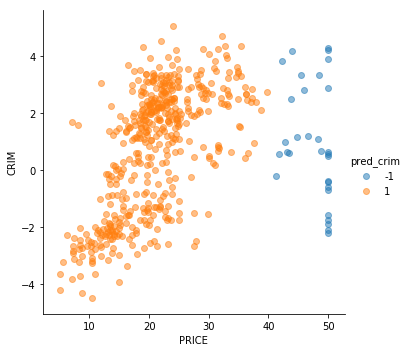

In [22]:
sns.lmplot(x='PRICE', y='CRIM', hue='pred_crim', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

In [23]:
clf = EllipticEnvelope(contamination=0.06)
clf.fit(df[['PRICE', 'RM']])
pred_rm = clf.predict(df[['PRICE', 'RM']])
proc_df['pred_rm'] = pred_rm

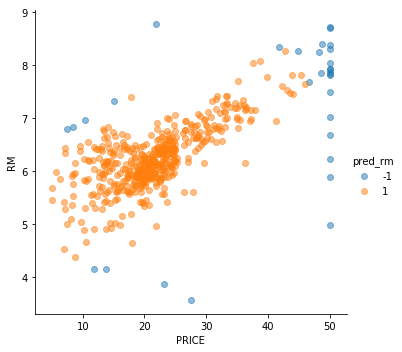

In [24]:
sns.lmplot(x='PRICE', y='RM', hue='pred_rm', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

In [25]:
clf = LocalOutlierFactor(n_neighbors=100, novelty=True,
                         contamination=0.035)
clf.fit(df[['PRICE', 'LSTAT']])
pred_ls = clf.predict(df[['PRICE', 'LSTAT']])
proc_df['pred_ls'] = pred_ls

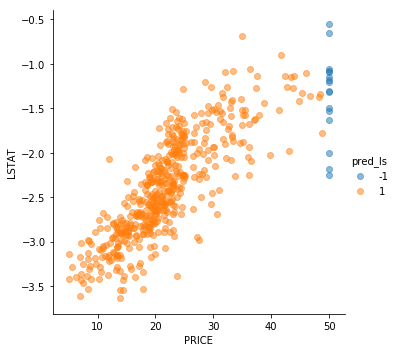

In [26]:
sns.lmplot(x='PRICE', y='LSTAT', hue='pred_ls', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

In [27]:
clf = LocalOutlierFactor(n_neighbors=100, novelty=True, contamination=0.05)
clf.fit(df[['PRICE', 'DIS']])
pred_dis = clf.predict(df[['PRICE', 'DIS']])
proc_df['pred_dis'] = pred_dis

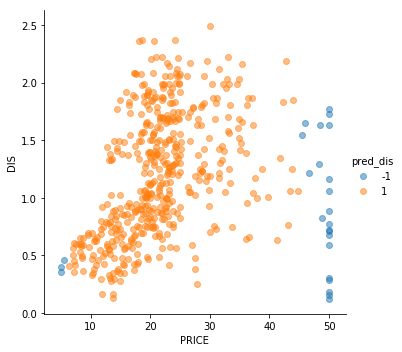

In [28]:
sns.lmplot(x='PRICE', y='DIS', hue='pred_dis', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

In [29]:
clf = IsolationForest(n_estimators=200, random_state=43,
                      contamination=0.07, max_samples=0.2)
clf.fit(df[['PRICE', 'NOX']])
pred_nox = clf.predict(df[['PRICE', 'NOX']])
proc_df['pred_nox'] = pred_nox

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/sklearn/ensemble/iforest.py:415: DeprecationWarning: threshold_ attribute is deprecated in 0.20 and will be removed in 0.22.
  " be removed in 0.22.", DeprecationWarning)


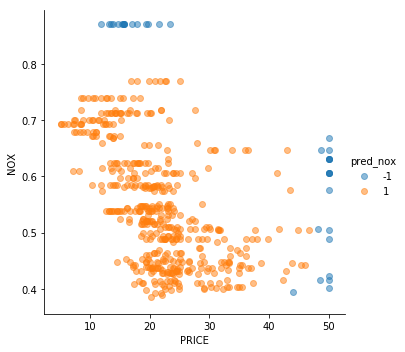

In [30]:
sns.lmplot(x='PRICE', y='NOX', hue='pred_nox', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

In [31]:
clf = EllipticEnvelope(contamination=0.05)
clf.fit(df[['PRICE', 'TAX']])
pred_tax = clf.predict(df[['PRICE', 'TAX']])
proc_df['pred_tax'] = pred_tax

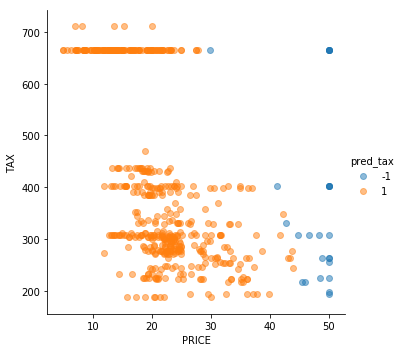

In [32]:
sns.lmplot(x='PRICE', y='TAX', hue='pred_tax', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

In [33]:
clf = IsolationForest(n_estimators=100, random_state=43,
                      contamination=0.01, max_samples=0.2)
clf.fit(df[['PRICE', 'B']])
pred_b = clf.predict(df[['PRICE', 'B']])
proc_df['pred_b'] = pred_b

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/sklearn/ensemble/iforest.py:415: DeprecationWarning: threshold_ attribute is deprecated in 0.20 and will be removed in 0.22.
  " be removed in 0.22.", DeprecationWarning)


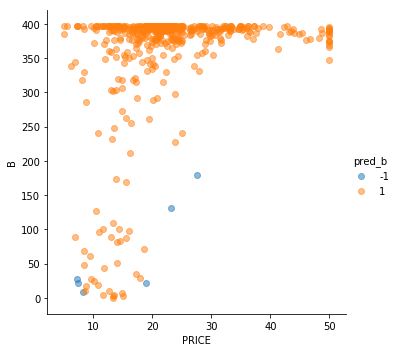

In [34]:
sns.lmplot(x='PRICE', y='B', hue='pred_b', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

In [35]:
clf = EllipticEnvelope(contamination=0.05)
clf.fit(df[['PRICE', 'AGE']])
pred_age = clf.predict(df[['PRICE', 'AGE']])
proc_df['pred_age'] = pred_age

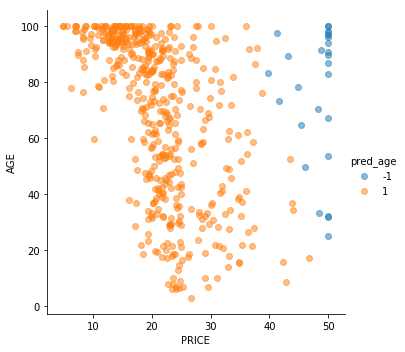

In [36]:
sns.lmplot(x='PRICE', y='AGE', hue='pred_age', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

In [37]:
clf = EllipticEnvelope(contamination=0.045)
clf.fit(df[['PRICE', 'PTRATIO']])
pred_pt = clf.predict(df[['PRICE', 'PTRATIO']])
proc_df['pred_pt'] = pred_pt

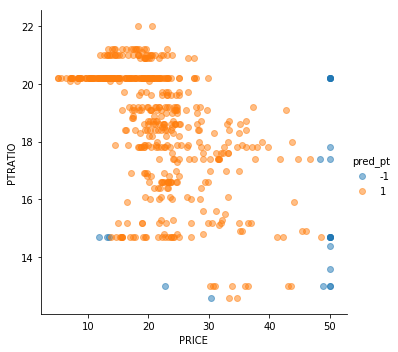

In [38]:
sns.lmplot(x='PRICE', y='PTRATIO', hue='pred_pt', data=proc_df,
           fit_reg=False, scatter_kws={'alpha': 0.5})

Checking the amount of 'clean' data left

In [39]:
clean_index = ((proc_df[proc_df.columns[proc_df.columns.str.contains('pred')]] == 1)
               .cumprod(axis=1).iloc[:, -1] == 1)

In [40]:
clean_index.sum() / df.shape[0]

0.8675889328063241

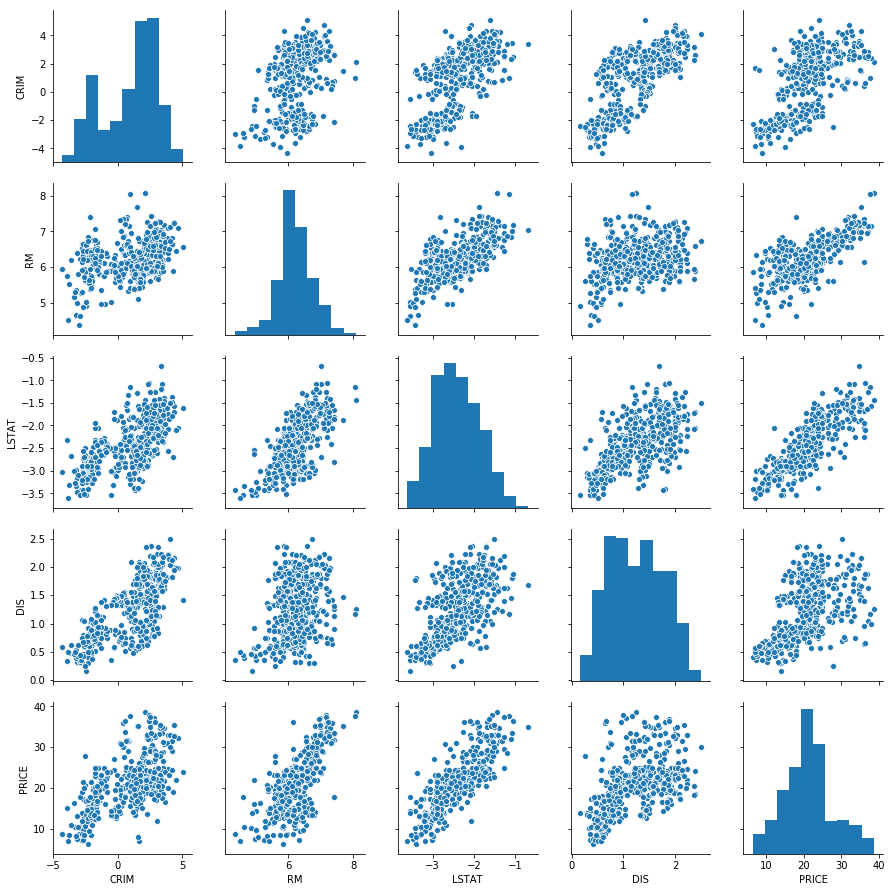

In [41]:
sns.pairplot(df.loc[clean_index, :],
             vars=['CRIM', 'RM', 'LSTAT',
                   'DIS', 'PRICE'])

In [42]:
X_train_cl, y_train_cl = X_train.loc[clean_index, :], y_train[clean_index]

In [43]:
reg.fit(X_train_cl, y_train_cl)

GradientBoostingRegressor(alpha=0.9, criterion='mae', init=None,
                          learning_rate=0.1, loss='ls', max_depth=8,
                          max_features='sqrt', max_leaf_nodes=None,
                          min_impurity_decrease=0.0, min_impurity_split=None,
                          min_samples_leaf=1, min_samples_split=2,
                          min_weight_fraction_leaf=0.0, n_estimators=19,
                          n_iter_no_change=None, presort='auto',
                          random_state=42, subsample=1.0, tol=0.0001,
                          validation_fraction=0.1, verbose=0, warm_start=False)

In [44]:
reg.score(X_test, y_test)

0.7042641138534352

## See what happens if only one anomaly detector is applied to the whole dataset

In [45]:
classifiers = {
    'Isolation Forest': IsolationForest(n_estimators=100,
                                        random_state=43,
                                        max_samples=0.2),
    'Robust Covariance (Minimum Covariance Determinant)': EllipticEnvelope(),
    'One Class SVM': OneClassSVM(gamma=0.05),
    'Local Outlier Factor': LocalOutlierFactor(n_neighbors=50,
                                               novelty=True)
}

Iterating over classifiers, contamination values and folds

In [46]:
kf = KFold(n_splits=5, random_state=42)

In [47]:
folds = list(kf.split(X_train, y_train))

In [48]:
con_vals = np.arange(0, 0.1, 0.005)

In [66]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

np.random.seed(42)

all_scores = {}

for k in (classifiers.keys()):
    cv_scores = {}
    print(k)
    for con in tqdm(con_vals):
        rs = np.zeros(len(folds))
        for idx, (train_index, test_index) in enumerate((folds), start=0):

            X_train2 = X_train.iloc[train_index, :]
            y_train2 = y_train.iloc[train_index]
            X_test2 = X_train.iloc[test_index, :]
            y_test2 = y_train.iloc[test_index]

            if (con == 0):
                X_train2_f = X_train2
                y_train2_f = y_train2
            elif (k != 'One Class SVM'):

                clf = classifiers[k].set_params(contamination=con)
                clf.fit(X_train2)

                X_train2_f = X_train2.loc[clf.predict(X_train2) == 1, :]
                y_train2_f = y_train2[clf.predict(X_train2) == 1]

            else:
                clf = classifiers[k].set_params(nu=con)
                clf.fit(X_train2)

                X_train2_f = X_train2.loc[clf.predict(X_train2) == 1, :]
                y_train2_f = y_train2[clf.predict(X_train2) == 1]

            reg.fit(X_train2_f, y_train2_f)

            rs[idx] = reg.score(X_test2, y_test2)

        cv_scores[con] = np.mean(rs), np.std(rs)

    all_scores[k] = cv_scores.copy()

Isolation Forest



Robust Covariance (Minimum Covariance Determinant)



One Class SVM



Local Outlier Factor


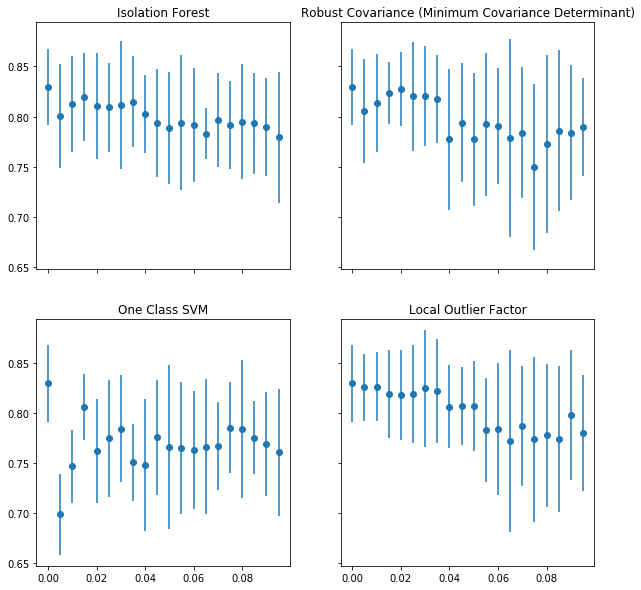

In [67]:
fig, axs = plt.subplots(nrows=2, ncols=2,
                        sharex=True, figsize=(10,10), sharey=True)

for k, ax in zip(all_scores.keys(), axs.flat):
    ax.set_title(f'{k}')
    ax.errorbar(all_scores[k].keys(),
                np.array(list(all_scores[k].values()))[:, 0],
                yerr=np.array(list(all_scores[k].values()))[:,1],
                fmt='o', label = k)

plt.show()

Robust Covariance @2% seems ok

In [68]:
clf = EllipticEnvelope(contamination=0.02)
clf.fit(X_train)

X_train_clear = X_train.loc[clf.predict(X_train) == 1, :]
y_train_clear = y_train.loc[clf.predict(X_train) == 1]

In [69]:
reg.fit(X_train_clear, y_train_clear)

GradientBoostingRegressor(alpha=0.9, criterion='mae', init=None,
                          learning_rate=0.1, loss='ls', max_depth=8,
                          max_features='sqrt', max_leaf_nodes=None,
                          min_impurity_decrease=0.0, min_impurity_split=None,
                          min_samples_leaf=1, min_samples_split=2,
                          min_weight_fraction_leaf=0.0, n_estimators=19,
                          n_iter_no_change=None, presort='auto',
                          random_state=42, subsample=1.0, tol=0.0001,
                          validation_fraction=0.1, verbose=0, warm_start=False)

In [70]:
reg.score(X_test, y_test)

0.8517929833916493

### See how the coefficients changed

is_tuned = 0 <- raw data <br />
is_tuned = 1 <- Elliptic Envelope @2% <br />
is_tuned = 2 <- hand-picked data <br />

In [78]:
reg.fit(X_train, y_train)
importances = {f: v for f, v in zip(df.columns,
                                    np.abs(reg.feature_importances_))}
importances['Test Score'] = reg.score(X_test, y_test)

reg.fit(X_train_clear, y_train_clear)
importances_tuned = {f: v for f, v in zip(df.columns,
                                          np.abs(reg.feature_importances_))}
importances_tuned['Test Score'] = reg.score(X_test, y_test)

reg.fit(X_train_cl, y_train_cl)
importances_tuned1 = {f: v for f, v in zip(df.columns,
                                           np.abs(reg.feature_importances_))}
importances_tuned1['Test Score'] = reg.score(X_test, y_test)

In [79]:
imp_df = pd.DataFrame([importances,
                       importances_tuned,
                       importances_tuned1],
                      index=[0, 1, 2])

In [80]:
imp_df['is_tuned'] = [0, 1, 2]

In [81]:
imp_df_l = pd.melt(imp_df.loc[:, imp_df.columns != 'Test Score'],
                   var_name='coef',
                   id_vars='is_tuned')
cv_df_l = pd.melt(imp_df.loc[:, ['Test Score', 'is_tuned']],
                  var_name='',
                  id_vars='is_tuned')

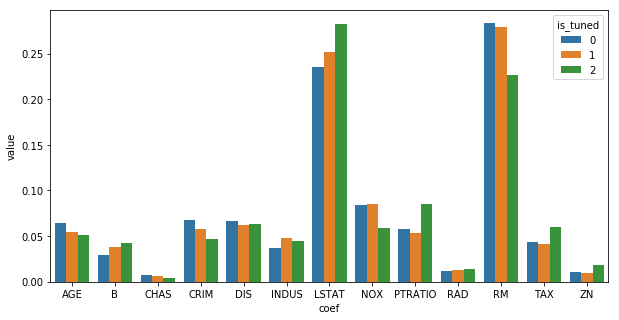

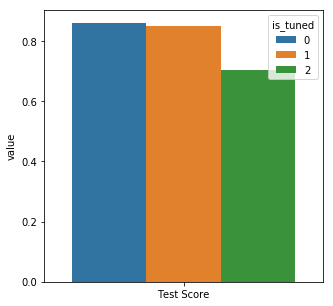

In [82]:
plt.figure(figsize=(10,5))
sns.barplot(x='coef', hue="is_tuned", y="value", data=imp_df_l)
plt.show()

plt.figure(figsize=(5,5))
sns.barplot(x='', hue="is_tuned", y="value", data=cv_df_l)
plt.show()